## Build a framework for making neural nets

### Task 1: Make a class for an object that can do implement the basic neuron and calculate gradients
The basic neuron is of the form:

$f\left(\displaystyle\sum_{i}{x_i w_i} + b\right)$

where $f(a)$ is a non-linear function whose output should be constrained between $[-1, 1]$, something like the $\tanh$ function.

In [1]:
%load_ext autoreload
%aimport value
%aimport neuralNet
%autoreload 1

In [2]:
from value import Value
from drawNodes import draw_dot

In [3]:
a = Value(1.0); a.label = 'a'
b = Value(3.0); b.label = 'b'

c = a*b; c.label = 'c'
c.backward()

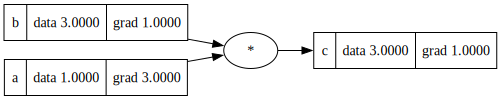

In [4]:
draw_dot(c)

In [5]:
x = Value(2.5); x.label = 'x'
y = Value(5.9); y.label = 'y'

z :Value = y * (x + 2)**1.5 -6.3 ; z.label = 'z'

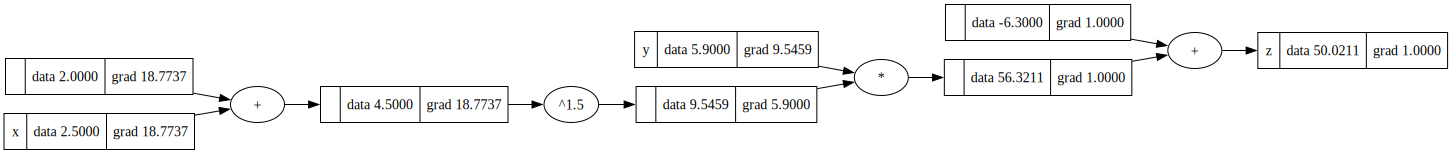

In [8]:
draw_dot(z)

In [7]:
z.backward()

In [9]:
from neuralNet import *

In [10]:
x = [2.0, 7.9, 5.5]

net = MLP(3, (4, 4, 1))
net(x)

Value(data=-0.9440435415966524)

In [11]:
len(net.parameters())

41

## Exercises as prescribed by Claude.

2-D toy array classifiers

In [ ]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np

X, y = make_moons(n_samples=150, noise=0.25, random_state=42)

- `X` is an ndarray, each row is a 2-D point, but with no information on which "Class" it belongs to.
- The `y` is sort of a mask array, 
    - The rows where `y == 0` are where the points in `X` corresponds to "Class 0".
    - The rows where `y == 1` are where the points in `X` corresponds to "Class 1".


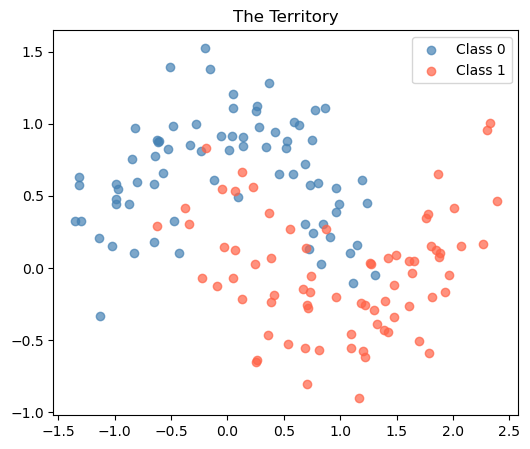

In [15]:
plt.figure(figsize=(6, 5), dpi=100)
plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', alpha=0.7, label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], c='tomato',   alpha=0.7, label='Class 1')
plt.legend(); plt.title('The Territory'); plt.show()

In [16]:
# The first 100 points will be the training data, 
X_train, y_train = X[:100], y[:100]

# The next 50 points will be the testing data.
X_test, y_test = X[100:], y[100:]

# Normalize using training stats only.
# As in a real world situation, we will only have access to the training data.
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0)

X_train_n = (X_train - mean) / std
X_test_n  = (X_test  - mean) / std  # same mean/std!


In [12]:
# Define a neural network
# For partitioning points on a 2-D plane
nn = MLP(2, (12, 8, 1))
# If an input is x, with a shape (2, )
x = np.array([7, 1])
# Prediction will be 
print(nn(x))

NameError: name 'np' is not defined

## Lets take an example data set where we want the neural net to predict if the point is inside the circle or not.

In [18]:
# Generate points
points = np.random.random((1024, 2))*10.0 - 5.0

# Make masks
mask = np.sqrt((points[:, 0] - 1.3)**2 + (points[:, 1] + 2)**2) < 3
mask_inv = np.invert(mask)

# y
y = np.array(mask, dtype=np.float64)

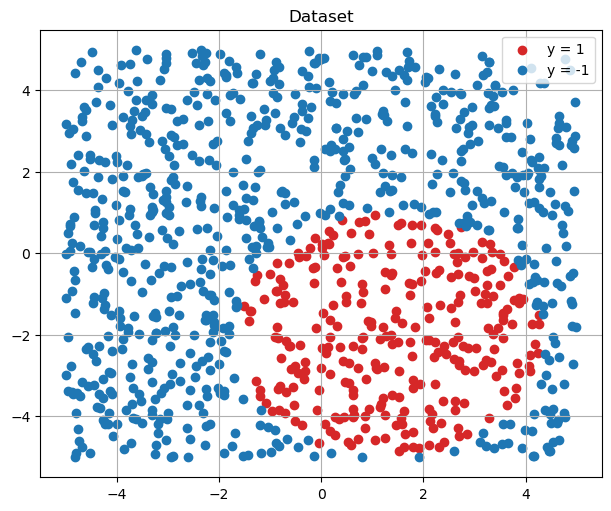

In [19]:
plt.subplots(figsize=(6, 5), layout='constrained')
plt.scatter(points[mask][:, 0], points[mask][:, 1], color="tab:red", label='y = 1')
plt.scatter(points[mask_inv][:, 0], points[mask_inv][:, 1], color="tab:blue", label='y = -1')
plt.title('Dataset')
plt.legend()
plt.grid()
plt.show()

## Implementing the training

In [20]:
preds = [nn(point) for point in points]
loss = sum((pred - act_val)**2 for pred, act_val in zip(preds, y))/y.shape[0]

pred_mask = np.array([True if pred.data>0 else False for pred in preds])

In [21]:
print(loss)

Value(data=0.9697110677584254)


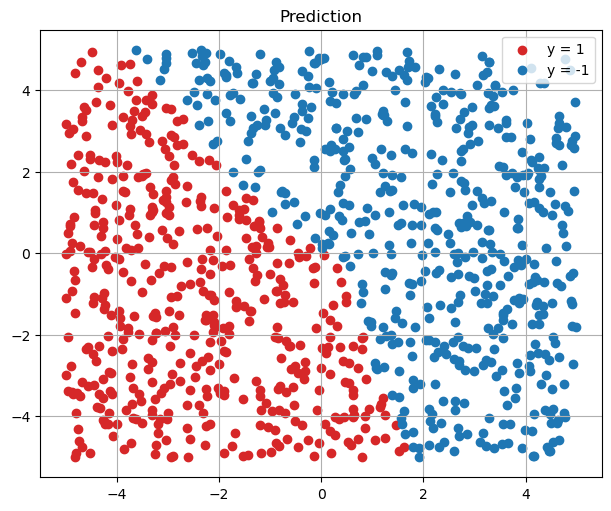

In [22]:
plt.subplots(figsize=(6, 5), layout='constrained')
plt.scatter(points[pred_mask][:, 0], points[pred_mask][:, 1], color="tab:red", label='y = 1')
pred_mask_inv = np.invert(pred_mask)
plt.scatter(points[pred_mask_inv][:, 0], points[pred_mask_inv][:, 1], color="tab:blue", label='y = -1')
plt.title('Prediction')
plt.legend()
plt.grid()
plt.show()

In [ ]:
losses = []
epochs = 200
lr = 0.5

for epoch in range(epochs):
    preds = [nn(point) for point in points]
    loss = sum((pred - act_val)**2 for pred, act_val in zip(preds, y))/y.shape[0]
    for param in nn.parameters(): param.grad = 0;
    loss.backward()
    # Gradient descent
    for p in nn.parameters(): p.data -= lr * p.grad
    losses.append(loss.data)

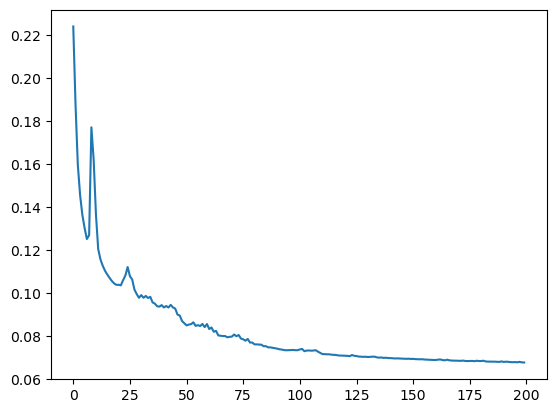

In [159]:
plt.plot([l for l in losses])